## ANN Model VS XGBoost Model

In [52]:
import tensorflow
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
df = pd.read_csv('Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [54]:
df.drop(['RowNumber','CustomerId','Surname'],axis=True,inplace = True)

In [55]:
## Converting the object - Number data types
from sklearn.preprocessing import LabelEncoder,  OneHotEncoder

lbe = LabelEncoder()
df['Gender'] = lbe.fit_transform(df['Gender'])
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [56]:
ohe  = OneHotEncoder()
encoded_ohe = ohe.fit_transform(df[['Geography']]).toarray()
encoded_df = pd.DataFrame(encoded_ohe, columns = ohe.get_feature_names_out())
df = pd.concat([encoded_df,df.drop('Geography', axis = 1)],axis=1)
df

,Geography_France,Geography_Germany,Geography_Spain,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1.0,0.0,0.0,619,0,42,2,0.00,1,1,1,101348.88,1
1,0.0,0.0,1.0,608,0,41,1,83807.86,1,0,1,112542.58,0
2,1.0,0.0,0.0,502,0,42,8,159660.80,3,1,0,113931.57,1
3,1.0,0.0,0.0,699,0,39,1,0.00,2,0,0,93826.63,0
4,0.0,0.0,1.0,850,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.0,0.0,0.0,771,1,39,5,0.00,2,1,0,96270.64,0
9996,1.0,0.0,0.0,516,1,35,10,57369.61,1,1,1,101699.77,0
9997,1.0,0.0,0.0,709,0,36,7,0.00,1,0,1,42085.58,1
9998,0.0,1.0,0.0,772,1,42,3,75075.31,2,1,0,92888.52,1


In [57]:
import pickle

with open('One_hot_encoder.pkl','wb') as obj:
    pickle.dump(ohe , obj)

with open('label_encoder.pkl','wb') as obj:
    pickle.dump(lbe , obj)

In [58]:
## DiVide the dataset into indepent and dependent features

X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

In [61]:
X_train.shape , y_train.shape , X_test.shape , y_test.shape

((8000, 12), (8000,), (2000, 12), (2000,))

In [62]:
## Scale these features
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [63]:
with open ('Scaler.pkl','wb')  as obj:
    pickle.dump(scaler , obj)

## ANN Implementation

In [64]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [65]:
model = Sequential([
        Dense(64 , activation='relu', input_shape = (X_train.shape[1],)),
        Dense(32,activation='relu'), ## HL2
        Dense(1,activation='sigmoid')  ## output layer
])

In [66]:
## compile the model
model.compile(optimizer='adam',loss="binary_crossentropy",metrics=['accuracy'])

In [67]:
from tensorflow.keras.callbacks import EarlyStopping , TensorBoard

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%M%D-%H%M%S")
tensoeflow_callback = TensorBoard(log_dir=log_dir , histogram_freq=1)

In [68]:
early_stopping_callback = EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)


In [69]:
history = model.fit(
        X_train ,y_train , validation_data=  (X_test,y_test) ,epochs = 100,
        callbacks = [tensoeflow_callback ,early_stopping_callback]


)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8119 - loss: 0.4464 - val_accuracy: 0.8350 - val_loss: 0.3928
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8444 - loss: 0.3821 - val_accuracy: 0.8535 - val_loss: 0.3553
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8556 - loss: 0.3535 - val_accuracy: 0.8520 - val_loss: 0.3516
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8583 - loss: 0.3445 - val_accuracy: 0.8570 - val_loss: 0.3522
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8608 - loss: 0.3391 - val_accuracy: 0.8620 - val_loss: 0.3448
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8618 - loss: 0.3357 - val_accuracy: 0.8625 - val_loss: 0.3479
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8614 - loss: 0.3338 - val_accuracy: 0.8615 - val_loss: 0.3417
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8616 - loss: 0.3311 - val_accu

In [70]:
model.save('ANN_model.h5')

## XGBoost Classifier

In [71]:
# Ensemble Models
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier

# Tree Model
from sklearn.tree import DecisionTreeClassifier

# Linear Model
from sklearn.linear_model import LogisticRegression

# Support Vector Machine
from sklearn.svm import SVC

# XGBoost Models
from xgboost import XGBClassifier, XGBRegressor

from sklearn.metrics import accuracy_score,precision_recall_curve,precision_score,recall_score,roc_auc_score,roc_curve,confusion_matrix

In [72]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [73]:
results  = {}
trained_models = {}  # Store actual model objects

## Train all models

for name, model in models.items():
    print(f"\n🔹 Training: {name}")

    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test,y_pred)
    results[name] = acc
    trained_models[name] = model  # Store the trained model

    print(f"Accuracy: {acc:.4f}")


best_model_name = max(results, key=results.get)
best_model_obj = trained_models[best_model_name]  # Get actual model object

print("\n🏆 Best Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])



🔹 Training: Logistic Regression
Accuracy: 0.8110

🔹 Training: Decision Tree
Accuracy: 0.7765

🔹 Training: Random Forest
Accuracy: 0.8685

🔹 Training: AdaBoost
Accuracy: 0.8585

🔹 Training: Gradient Boosting
Accuracy: 0.8640

🔹 Training: SVM
Accuracy: 0.8560

🔹 Training: XGBoost
Accuracy: 0.8580

🏆 Best Model: Random Forest
Best Accuracy: 0.8685


## Random Forest Gives Best Accuracy in classifing customer churn

In [74]:
with open ('Random_forest_model.pkl','wb') as obj:
    pickle.dump(best_model_obj, obj)
    
print(f"✅ Best model '{best_model_name}' saved as 'Random_forest_model.pkl'")

✅ Best model 'Random Forest' saved as 'Random_forest_model.pkl'


In [75]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
    from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("=" * 55)
print("       MODEL COMPARISON: RF  vs  ANN")
print("=" * 55)

# --- Random Forest ---
with open("model.pkl", "rb") as f:
    rf_model = pickle.load(f)
print("✅ Random Forest model loaded")

# --- ANN (TensorFlow/Keras) ---
try:

    ann_model = load_model("ann_model.h5") 
    print("✅ ANN model loaded")
except Exception as e:
    print(f"❌ ANN load error: {e}")
    print("   Try: ann_model = load_model('ann_model.keras')")
    raise


#  PREDICTIONS

# Random Forest
rf_pred       = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# ANN  (sigmoid output → probability)
ann_pred_proba = ann_model.predict(X_test, verbose=0).flatten()
ann_pred       = (ann_pred_proba >= 0.5).astype(int)

#  METRICS

def get_metrics(y_true, y_pred, y_proba, name):
    return {
        "Model"    : name,
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall"   : recall_score(y_true, y_pred),
        "F1 Score" : f1_score(y_true, y_pred),
        "ROC-AUC"  : roc_auc_score(y_true, y_proba),
    }

rf_metrics  = get_metrics(y_test, rf_pred,  rf_pred_proba,  "Random Forest")
ann_metrics = get_metrics(y_test, ann_pred, ann_pred_proba, "ANN")

# ─────────────────────────────────────────────
# 5. PRINT COMPARISON TABLE
# ─────────────────────────────────────────────
print(f"{'Metric':<12} {'Random Forest':>15} {'ANN':>10}  {'Winner':>10}")
print("-" * 52)
metrics_keys = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
for key in metrics_keys:
    rf_val  = rf_metrics[key]
    ann_val = ann_metrics[key]
    winner  = "RF 🌲" if rf_val > ann_val else "ANN 🧠" if ann_val > rf_val else "Tie 🤝"
    print(f"{key:<12} {rf_val:>15.4f} {ann_val:>10.4f}  {winner:>10}")
print("-" * 52)

print("\n── Random Forest Classification Report ──")
print(classification_report(y_test, rf_pred))
print("── ANN Classification Report ──")
print(classification_report(y_test, ann_pred))

# ─────────────────────────────────────────────
# 6. VISUALIZATIONS
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 5))
fig.suptitle("Random Forest  vs  ANN — Model Comparison", fontsize=16, fontweight="bold", y=1.02)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

COLORS = {"rf": "#2ECC71", "ann": "#3498DB"}

# ── Plot 1: ROC Curve ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_pred_proba)
ann_fpr, ann_tpr, _ = roc_curve(y_test, ann_pred_proba)
rf_auc  = roc_auc_score(y_test, rf_pred_proba)
ann_auc = roc_auc_score(y_test, ann_pred_proba)

ax1.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC = 0.50)")
ax1.plot(rf_fpr,  rf_tpr,  color=COLORS["rf"],  lw=2.5,
         label=f"Random Forest  (AUC = {rf_auc:.4f})")
ax1.plot(ann_fpr, ann_tpr, color=COLORS["ann"], lw=2.5, linestyle="--",
         label=f"ANN            (AUC = {ann_auc:.4f})")

ax1.fill_between(rf_fpr,  rf_tpr,  alpha=0.08, color=COLORS["rf"])
ax1.fill_between(ann_fpr, ann_tpr, alpha=0.08, color=COLORS["ann"])

ax1.set_xlabel("False Positive Rate", fontsize=11)
ax1.set_ylabel("True Positive Rate",  fontsize=11)
ax1.set_title("ROC AUC Curve",        fontsize=13, fontweight="bold")
ax1.legend(loc="lower right", fontsize=9)
ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1.02])
ax1.grid(alpha=0.3)

# ── Plot 2: Metric Bar Chart ───────────────────────────────────
ax2 = fig.add_subplot(gs[1])

x     = np.arange(len(metrics_keys))
width = 0.35
rf_vals  = [rf_metrics[k]  for k in metrics_keys]
ann_vals = [ann_metrics[k] for k in metrics_keys]

bars_rf  = ax2.bar(x - width/2, rf_vals,  width, label="Random Forest",
                   color=COLORS["rf"],  alpha=0.85, edgecolor="white")
bars_ann = ax2.bar(x + width/2, ann_vals, width, label="ANN",
                   color=COLORS["ann"], alpha=0.85, edgecolor="white")

# Value labels on bars
for bar in bars_rf:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)
for bar in bars_ann:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)

ax2.set_xticks(x)
ax2.set_xticklabels(metrics_keys, rotation=20, ha="right", fontsize=9)
ax2.set_ylim([0, 1.15])
ax2.set_ylabel("Score", fontsize=11)
ax2.set_title("All Metrics Comparison", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

# ── Plot 3: Confusion Matrices (side by side) ─────────────────
ax3 = fig.add_subplot(gs[2])
ax3.axis("off")

# Draw two mini confusion matrices in one axes using text/patches
import matplotlib.patches as mpatches

def draw_mini_cm(ax, cm, title, x_offset, color):
    labels = ["TN", "FP", "FN", "TP"]
    values = cm.ravel()
    positions = [(0,1),(1,1),(0,0),(1,0)]
    ax.text(x_offset + 0.25, 0.97, title, ha="center", va="top",
            fontsize=10, fontweight="bold", color=color,
            transform=ax.transAxes)
    alphas = [0.25, 0.55, 0.55, 0.85]
    for i, (c, r) in enumerate(positions):
        rect = mpatches.FancyBboxPatch(
            (x_offset + c * 0.22, 0.55 + r * 0.22), 0.20, 0.20,
            boxstyle="round,pad=0.01", linewidth=1,
            edgecolor=color, facecolor=color,
            alpha=alphas[i], transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(rect)
        ax.text(x_offset + c * 0.22 + 0.10,
                0.55 + r * 0.22 + 0.10,
                f"{labels[i]}\n{values[i]}",
                ha="center", va="center", fontsize=9,
                fontweight="bold", color="white",
                transform=ax.transAxes)

    ax.text(x_offset + 0.10, 0.50, "Pred: 0", ha="center", fontsize=8,
            transform=ax.transAxes, color="gray")
    ax.text(x_offset + 0.32, 0.50, "Pred: 1", ha="center", fontsize=8,
            transform=ax.transAxes, color="gray")
    ax.text(x_offset - 0.04, 0.66, "Act: 1", ha="right", fontsize=8,
            transform=ax.transAxes, color="gray")
    ax.text(x_offset - 0.04, 0.88, "Act: 0", ha="right", fontsize=8,
            transform=ax.transAxes, color="gray")

cm_rf  = confusion_matrix(y_test, rf_pred)
cm_ann = confusion_matrix(y_test, ann_pred)

draw_mini_cm(ax3, cm_rf,  "Random Forest 🌲", 0.08,  COLORS["rf"])
draw_mini_cm(ax3, cm_ann, "ANN 🧠",           0.55, COLORS["ann"])
ax3.set_title("Confusion Matrices", fontsize=13, fontweight="bold", pad=12)

plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("\n✅ Chart saved → model_comparison.png")

# ─────────────────────────────────────────────
# 7. FINAL VERDICT
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
wins_rf  = sum(1 for k in metrics_keys if rf_metrics[k]  > ann_metrics[k])
wins_ann = sum(1 for k in metrics_keys if ann_metrics[k] > rf_metrics[k])
if wins_rf > wins_ann:
    print(f"🏆 WINNER: Random Forest  ({wins_rf}/{len(metrics_keys)} metrics)")
elif wins_ann > wins_rf:
    print(f"🏆 WINNER: ANN            ({wins_ann}/{len(metrics_keys)} metrics)")
else:
    print("🤝 It's a TIE — both models perform similarly!")
print("=" * 55)

IndentationError: unexpected indent (691951590.py, line 5)

In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("       MODEL COMPARISON: RANDOM FOREST vs ANN")
print("=" * 60)

# --- Load Random Forest Model ---
try:
    with open("Random_forest_model.pkl", "rb") as f:
        rf_model = pickle.load(f)
    print("✅ Random Forest model loaded successfully")
except Exception as e:
    print(f"⚠️  Could not load Random Forest: {e}")
    print("   Using best_model_obj from training...")
    rf_model = best_model_obj

# --- Load ANN Model ---
try:
    ann_model = load_model("ANN_model.h5")
    print("✅ ANN model loaded successfully")
except Exception as e:
    print(f"❌ ANN load error: {e}")
    print("   Trying alternative path...")
    try:
        ann_model = load_model("model.h5")
        print("✅ ANN model loaded (model.h5)")
    except:
        raise

print("\n" + "=" * 60)

# ─────────────────────────────────────────────
# PREDICTIONS
# ─────────────────────────────────────────────

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# ANN (sigmoid output → probability)
ann_pred_proba = ann_model.predict(X_test, verbose=0).flatten()
ann_pred = (ann_pred_proba >= 0.5).astype(int)

print(f"Random Forest predictions (first 10): {rf_pred[:10]}")
print(f"ANN predictions (first 10): {ann_pred[:10]}")

# ─────────────────────────────────────────────
# CALCULATE METRICS
# ─────────────────────────────────────────────

def get_metrics(y_true, y_pred, y_proba, name):
    return {
        "Model"    : name,
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall"   : recall_score(y_true, y_pred),
        "F1 Score" : f1_score(y_true, y_pred),
        "ROC-AUC"  : roc_auc_score(y_true, y_proba),
    }

rf_metrics  = get_metrics(y_test, rf_pred,  rf_pred_proba,  "Random Forest")
ann_metrics = get_metrics(y_test, ann_pred, ann_pred_proba, "ANN")

# ─────────────────────────────────────────────
# PRINT COMPARISON TABLE
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"{'Metric':<12} {'Random Forest':>15} {'ANN':>15}  {'Winner':>12}")
print("-" * 60)
metrics_keys = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
for key in metrics_keys:
    rf_val  = rf_metrics[key]
    ann_val = ann_metrics[key]
    winner  = "RF 🌲" if rf_val > ann_val else "ANN 🧠" if ann_val > rf_val else "Tie 🤝"
    print(f"{key:<12} {rf_val:>15.4f} {ann_val:>15.4f}  {winner:>12}")
print("-" * 60)

print("\n📊 RANDOM FOREST - Classification Report")
print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))

print("\n📊 ANN - Classification Report")
print(classification_report(y_test, ann_pred, target_names=["No Churn", "Churn"]))

       MODEL COMPARISON: RANDOM FOREST vs ANN
✅ Random Forest model loaded successfully
✅ ANN model loaded successfully

Random Forest predictions (first 10): [0 0 0 0 0 0 0 0 0 0]
ANN predictions (first 10): [0 0 0 0 0 0 0 0 0 0]

Metric         Random Forest             ANN        Winner
------------------------------------------------------------
Accuracy              0.8670          0.8655          RF 🌲
Precision             0.7550          0.7719         ANN 🧠
Recall                0.4784          0.4478          RF 🌲
F1 Score              0.5857          0.5668          RF 🌲
ROC-AUC               0.8574          0.8582         ANN 🧠
------------------------------------------------------------

📊 RANDOM FOREST - Classification Report
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92      1607
       Churn       0.76      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72


✅ Main comparison chart saved → model_comparison_metrics.png
✅ Confusion matrices saved → confusion_matrices.png


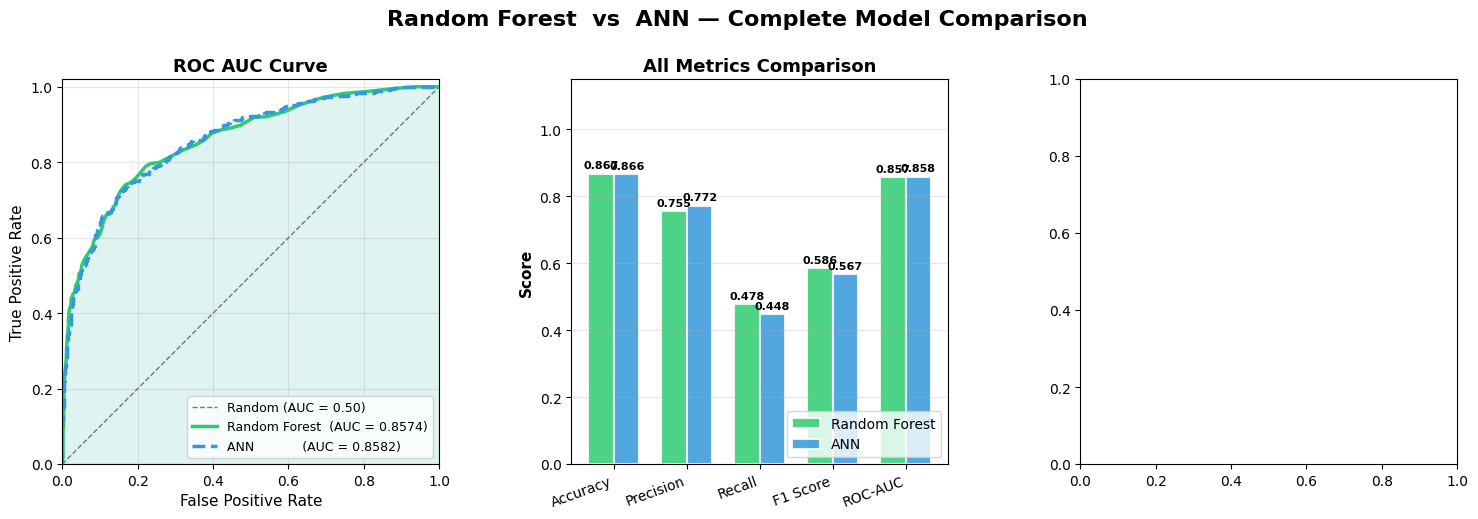

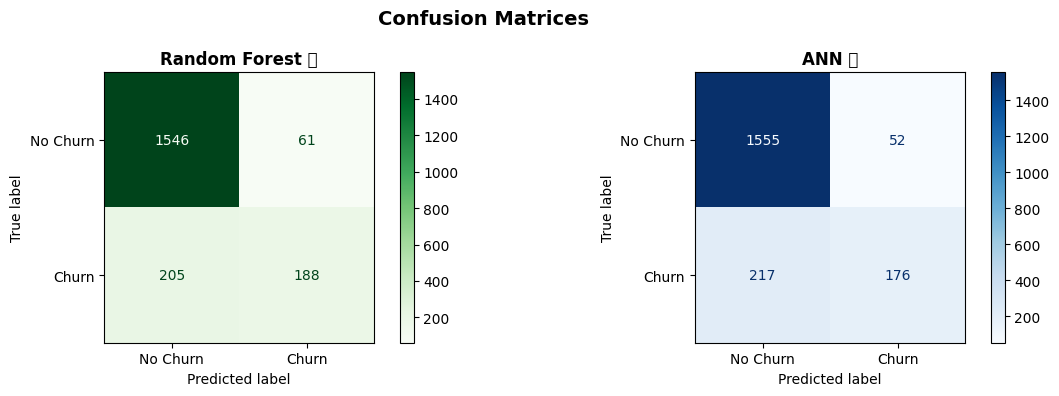


🏆 WINNER: Random Forest  (3/5 metrics)
   • Reason: Better overall performance on this dataset
   • Advantages: Faster training, easier to deploy, interpretable


In [ ]:
# ─────────────────────────────────────────────
# VISUALIZATIONS
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(18, 5))
fig.suptitle("Random Forest  vs  ANN — Complete Model Comparison", 
             fontsize=16, fontweight="bold", y=1.02)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

COLORS = {"rf": "#2ECC71", "ann": "#3498DB"}

# ── Plot 1: ROC Curve ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_pred_proba)
ann_fpr, ann_tpr, _ = roc_curve(y_test, ann_pred_proba)
rf_auc  = roc_auc_score(y_test, rf_pred_proba)
ann_auc = roc_auc_score(y_test, ann_pred_proba)

ax1.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC = 0.50)")
ax1.plot(rf_fpr,  rf_tpr,  color=COLORS["rf"],  lw=2.5,
         label=f"Random Forest  (AUC = {rf_auc:.4f})")
ax1.plot(ann_fpr, ann_tpr, color=COLORS["ann"], lw=2.5, linestyle="--",
         label=f"ANN            (AUC = {ann_auc:.4f})")

ax1.fill_between(rf_fpr,  rf_tpr,  alpha=0.08, color=COLORS["rf"])
ax1.fill_between(ann_fpr, ann_tpr, alpha=0.08, color=COLORS["ann"])

ax1.set_xlabel("False Positive Rate", fontsize=11)
ax1.set_ylabel("True Positive Rate",  fontsize=11)
ax1.set_title("ROC AUC Curve",        fontsize=13, fontweight="bold")
ax1.legend(loc="lower right", fontsize=9)
ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1.02])
ax1.grid(alpha=0.3)

# ── Plot 2: Metric Bar Chart ───────────────────────────────────
ax2 = fig.add_subplot(gs[1])

x     = np.arange(len(metrics_keys))
width = 0.35
rf_vals  = [rf_metrics[k]  for k in metrics_keys]
ann_vals = [ann_metrics[k] for k in metrics_keys]

bars_rf  = ax2.bar(x - width/2, rf_vals,  width, label="Random Forest",
                   color=COLORS["rf"],  alpha=0.85, edgecolor="white", linewidth=1.5)
bars_ann = ax2.bar(x + width/2, ann_vals, width, label="ANN",
                   color=COLORS["ann"], alpha=0.85, edgecolor="white", linewidth=1.5)

# Value labels on bars
for bar in bars_rf:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
for bar in bars_ann:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax2.set_xticks(x)
ax2.set_xticklabels(metrics_keys, rotation=20, ha="right", fontsize=10)
ax2.set_ylim([0, 1.15])
ax2.set_ylabel("Score", fontsize=11, fontweight="bold")
ax2.set_title("All Metrics Comparison", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10, loc="lower right")
ax2.grid(axis="y", alpha=0.3)

# ── Plot 3: Confusion Matrices (side by side) ─────────────────
ax3 = fig.add_subplot(gs[2])

cm_rf  = confusion_matrix(y_test, rf_pred)
cm_ann = confusion_matrix(y_test, ann_pred)

# Plot confusion matrices using heatmap
from sklearn.metrics import ConfusionMatrixDisplay

# Create two subplots for confusion matrices
fig2, axes = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")

ConfusionMatrixDisplay(cm_rf, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[0], cmap="Greens", colorbar=True)
axes[0].set_title("Random Forest 🌲", fontsize=12, fontweight="bold")

ConfusionMatrixDisplay(cm_ann, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[1], cmap="Blues", colorbar=True)
axes[1].set_title("ANN 🧠", fontsize=12, fontweight="bold")

plt.tight_layout()

# Save main comparison plot
fig.savefig("model_comparison_metrics.png", dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
print("\n✅ Main comparison chart saved → model_comparison_metrics.png")

# Save confusion matrices plot
fig2.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
print("✅ Confusion matrices saved → confusion_matrices.png")

plt.show()

# ─────────────────────────────────────────────
# FINAL VERDICT
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
wins_rf  = sum(1 for k in metrics_keys if rf_metrics[k]  > ann_metrics[k])
wins_ann = sum(1 for k in metrics_keys if ann_metrics[k] > rf_metrics[k])

if wins_rf > wins_ann:
    print(f"🏆 WINNER: Random Forest  ({wins_rf}/{len(metrics_keys)} metrics)")
    print(f"   • Reason: Better overall performance on this dataset")
    print(f"   • Advantages: Faster training, easier to deploy, interpretable")
elif wins_ann > wins_rf:
    print(f"🏆 WINNER: ANN            ({wins_ann}/{len(metrics_keys)} metrics)")
    print(f"   • Reason: Superior deep learning capabilities")
    print(f"   • Advantages: Can capture complex patterns, flexible architecture")
else:
    print("🤝 It's a TIE — both models perform similarly!")

print("=" * 60)

##  Random Forest Prform best bcz it wins in recall , Accuracy , F1 score

## ANN model perform bettern on precision,specificity. both are better but Random_forest performs litte better 